In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# 1. Download the dataset archive quietly
!wget -q https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz

# 2. Untar the archive directly into Kaggle's working directory
!tar -xzf flower_photos.tgz -C /kaggle/working/

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import os

In [4]:
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001
INPUT_SIZE = 224

# Set compute device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Primary compute device: {device}")

Primary compute device: cuda


In [5]:
# Define separate transformation pipelines for Training and Validation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.RandomHorizontalFlip(),  # Augmentation to prevent overfitting
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [6]:
# 1. Load full raw dataset
data_dir = "/kaggle/working/flower_photos"
full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms['train'])

In [7]:
# 2. Perform 80/20 train/validation split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [8]:
# 3. Override validation subset transform so validation images aren't randomly flipped
val_dataset.dataset.transform = data_transforms['val']

In [9]:
# 4. Construct DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [10]:
print(f"Training set: {len(train_dataset)} images | Validation set: {len(val_dataset)} images")

Training set: 2936 images | Validation set: 734 images


In [11]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# 1. Load pretrained MobileNetV2
model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 153MB/s]


In [12]:
# 2. Freeze all foundational layers
for param in model.parameters():
    param.requires_grad = False

In [13]:
# 3. Modify MobileNet's final classification layer
# MobileNetV2 stores its final Linear layer inside a Sequential block at index 1
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 5)

In [14]:
# 4. Unfreeze parameters for ONLY the new classification layer
for param in model.classifier[1].parameters():
    param.requires_grad = True

In [15]:
# 5. Enable Multi-GPU training across both Kaggle T4 GPUs
if torch.cuda.device_count() > 1:
    print(f"Detected {torch.cuda.device_count()} GPUs! Wrapping model in DataParallel...")
    model = nn.DataParallel(model)


Detected 2 GPUs! Wrapping model in DataParallel...


In [16]:
# Move the model to GPU memory
model = model.to(device)

In [17]:
# 6. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [18]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs):
    # Local history dictionary to log metrics
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 30)
        
        # ================= TRAINING PHASE =================
        model.train()  # Enables Dropout layers in training mode
        train_correct = 0
        train_total = 0
        running_loss = 0.0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()            # Clear old gradients
            outputs = model(images)          # Forward pass
            loss = criterion(outputs, labels) # Calculate Cross-Entropy Loss
            loss.backward()                  # Backward pass (compute gradients)
            optimizer.step()                 # Update layer weights

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1) # Extract class prediction with highest logit
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            # Print status every 20 batches
            if (i + 1) % 20 == 0:
                batch_acc = (preds == labels).sum().item() / labels.size(0)
                print(f"[Batch {i+1}/{len(train_loader)}] Loss: {loss.item():.4f} | Batch Acc: {batch_acc:.4f}")

        train_acc = train_correct / train_total
        avg_train_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1} Summary - Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")

        # ================= VALIDATION PHASE =================
        model.eval()  # Disables Dropout for evaluation
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():  # Disable gradient calculation to conserve VRAM
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        print(f"Validation Accuracy: {val_acc:.4f}")
        
        # Save metrics locally
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
    return history

In [19]:
# Execute training
history = train_model(model, criterion, optimizer, train_loader, val_loader, epochs=EPOCHS)


Epoch 1/50
------------------------------
[Batch 20/92] Loss: 1.2526 | Batch Acc: 0.5000
[Batch 40/92] Loss: 0.7897 | Batch Acc: 0.8750
[Batch 60/92] Loss: 0.7876 | Batch Acc: 0.7500
[Batch 80/92] Loss: 0.6667 | Batch Acc: 0.7500
Epoch 1 Summary - Train Loss: 0.9418 | Train Acc: 0.7115
Validation Accuracy: 0.8624

Epoch 2/50
------------------------------
[Batch 20/92] Loss: 0.4369 | Batch Acc: 0.8750
[Batch 40/92] Loss: 0.4649 | Batch Acc: 0.9688
[Batch 60/92] Loss: 0.5108 | Batch Acc: 0.9062
[Batch 80/92] Loss: 0.5405 | Batch Acc: 0.8125
Epoch 2 Summary - Train Loss: 0.5556 | Train Acc: 0.8396
Validation Accuracy: 0.9019

Epoch 3/50
------------------------------
[Batch 20/92] Loss: 0.2885 | Batch Acc: 0.9688
[Batch 40/92] Loss: 0.4427 | Batch Acc: 0.8438
[Batch 60/92] Loss: 0.5332 | Batch Acc: 0.8750
[Batch 80/92] Loss: 0.4871 | Batch Acc: 0.8438
Epoch 3 Summary - Train Loss: 0.4509 | Train Acc: 0.8658
Validation Accuracy: 0.9060

Epoch 4/50
------------------------------
[Batch 20

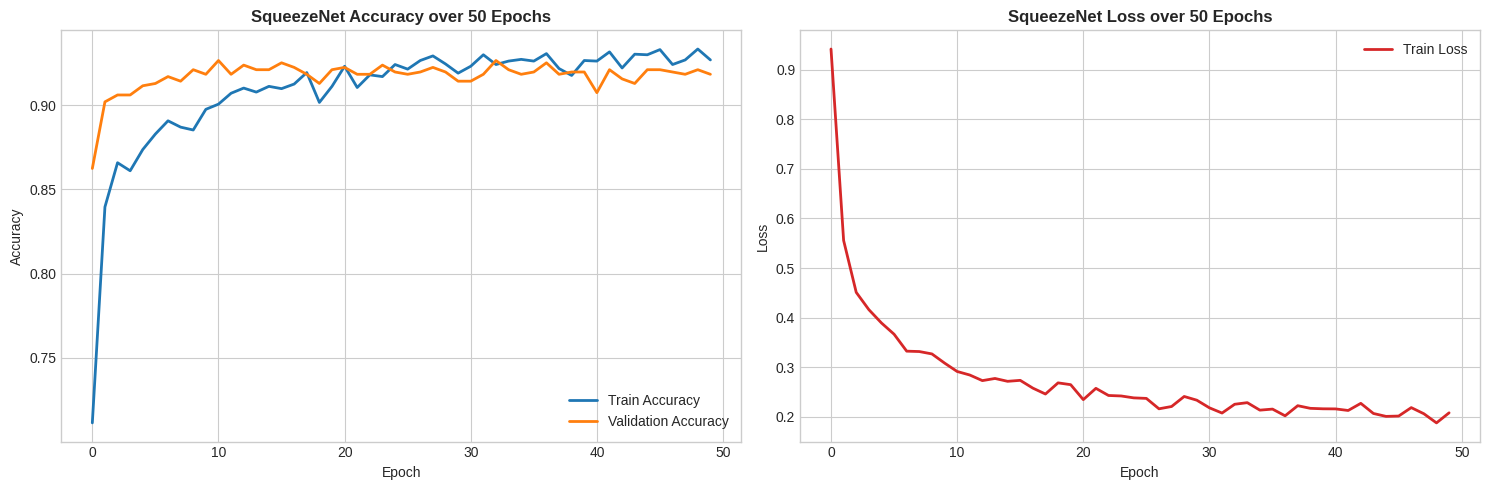

In [20]:
import matplotlib.pyplot as plt

# Set aesthetic style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Accuracy History
axes[0].plot(history['train_acc'], label='Train Accuracy', color='#1f77b4', linewidth=2)
axes[0].plot(history['val_acc'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
axes[0].set_title('SqueezeNet Accuracy over 50 Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot Loss History
axes[1].plot(history['train_loss'], label='Train Loss', color='#d62728', linewidth=2)
axes[1].set_title('SqueezeNet Loss over 50 Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# Save Model Checkpoint
save_path = '/kaggle/working/squeezenet_5flowers_model.pth'
torch.save(model.state_dict(), save_path)
print(f"Model weights successfully saved to {save_path}")

Model weights successfully saved to /kaggle/working/squeezenet_5flowers_model.pth


In [22]:
import random
import matplotlib.pyplot as plt

# 1. Retrieve the list of flower class names 
class_names = full_dataset.classes

In [23]:
# 2. Lock the model into evaluation mode
model.eval()

DataParallel(
  (module): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=(1

In [ ]:
# 3. Select a random image from the validation set
random_idx = random.randint(0, len(val_dataset) - 1)
image_tensor, actual_label_idx = val_dataset[random_idx]

In [25]:
# 4. Add a batch dimension: (C, H, W) -> (1, C, H, W) and move to GPU
image_batch = image_tensor.unsqueeze(0).to(device)

In [26]:
# 5. Perform the forward pass (inference)
with torch.no_grad():
    output = model(image_batch)
    # Extract the index of the highest logit score
    _, predicted_idx = torch.max(output, 1)

In [27]:
# Map the numerical indices back to the string names
actual_flower = class_names[actual_label_idx]
predicted_flower = class_names[predicted_idx.item()]

In [28]:
# 6. Un-normalize the image for human viewing
# Move tensor to CPU, then convert to a NumPy array
image_display = image_tensor.permute(1, 2, 0).cpu().numpy()

In [29]:
# Apply the inverse of the ImageNet normalization math
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image_display = std * image_display + mean
image_display = image_display.clip(0, 1) # Force pixel values into valid [0, 1] range

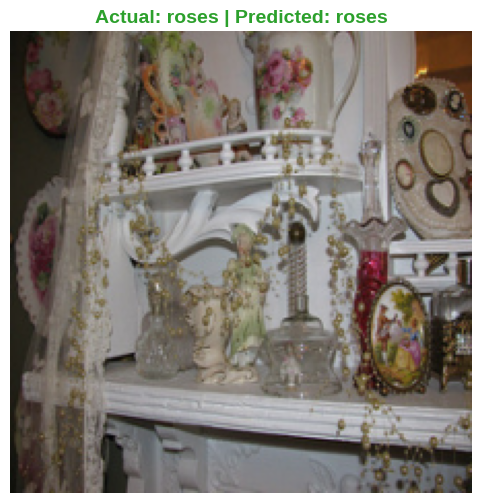

In [30]:
# 7. Plot the result
plt.figure(figsize=(6, 6))
plt.imshow(image_display)

# Title is green if correct, red if the model made a mistake
title_color = "#2ca02c" if actual_flower == predicted_flower else "#d62728"
plt.title(f"Actual: {actual_flower} | Predicted: {predicted_flower}", color=title_color, fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()